<a href="https://colab.research.google.com/github/shanchepngen-ux/ML-For-Engineering/blob/main/Redone_Week3_Assignment0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Problem and Intended AI/ML Outcome

## Project Problem

Artisanal and small-scale mining activities are often carried out with limited geotechnical planning, engineering monitoring and safety infrastructure. As a result, unstable slopes and mine-pit walls can fail, particularly during or after periods of heavy rainfall. Such failures can cause injuries, fatalities and significant damage to mining communities.

This project aims to investigate how Machine Learning can be used to identify areas that are susceptible to slope instability and landslides in and around artisanal mining areas.

## Intended AI/ML Outcome

The intended AI/ML system will use environmental and geospatial information to classify areas according to their landslide or slope-instability susceptibility.

The longer-term objective is to develop a system that could classify active artisanal mining areas into risk categories such as:

* Low Risk
* Medium Risk
* High Risk

and eventually estimate the probability of a mine-pit or surrounding slope failure following environmental triggers such as heavy rainfall.

For this assignment, a publicly available landslide-susceptibility dataset from Hugging Face will be used as a relevant proxy dataset because a sufficiently large publicly available dataset specifically containing labelled artisanal mine-pit collapses was not identified. The approach developed using this dataset could subsequently be adapted to artisanal mining by incorporating mine locations, pit geometry, rainfall, soil properties, geological information and satellite-derived ground deformation.


# Data Required

To develop the proposed artisanal mining hazard prediction system, several categories of data would be required.

### 1. Topographic Data

* Digital Elevation Model (DEM)
* Elevation
* Slope angle
* Aspect
* Terrain curvature
* Drainage characteristics

These variables can help describe the physical characteristics and stability of a mining slope.

### 2. Weather and Environmental Data

* Daily rainfall
* Cumulative rainfall over 3, 7 and 14 days
* Soil moisture
* Temperature
* Surface water conditions

Rainfall and soil moisture are particularly important because water infiltration can increase pore-water pressure and reduce slope stability.

### 3. Geological and Soil Data

* Soil type
* Clay, sand and silt content
* Geological formation
* Rock type
* Geological structures such as faults where available

These variables can help describe the strength and behaviour of the material forming the slope.

### 4. Remote Sensing Data

* Sentinel-1 SAR data
* Sentinel-2 multispectral imagery
* Surface deformation
* Land-cover change
* Mining disturbance

Satellite data could be used to monitor changes in the ground surface and identify areas of increasing instability.

### 5. Mining-Specific Data

* Location of mining pits
* Pit depth
* Pit width
* Pit-wall slope angle
* Excavation method
* Presence of support structures
* Water accumulation in pits
* Previous mine failures

### 6. Historical Hazard Data

* Historical landslide locations
* Historical mine-collapse locations
* Date of each failure
* Location coordinates
* Environmental conditions before the failure

These historical events would provide the target labels required for supervised machine learning.

For this assignment, a publicly available landslide-susceptibility dataset from Hugging Face will be used as a proxy because it contains relevant environmental and geospatial information and a hazard-related target variable.


In [23]:
# The standard load_dataset() function fails with DataFilesNotFoundError because
# this repository contains raw, nested HDF5 files rather than supported tabular
# files (like CSV or Parquet) or an integrated loading script.
#
# Instead of using load_dataset, we must access the files directly via the HF Hub.
print("Standard load_dataset is not supported for this repository configuration.")
print("Use huggingface_hub.hf_hub_download to access individual .h5 files directly.")

Standard load_dataset is not supported for this repository configuration.
Use huggingface_hub.hf_hub_download to access individual .h5 files directly.


In [5]:
from huggingface_hub import hf_hub_download
import h5py

# Download a single validation image file from the nested repository structure
sample_file_path = hf_hub_download(
    repo_id="ibm-nasa-geospatial/Landslide4sense",
    filename="images/validation/image_1.h5",
    repo_type="dataset"
)

# Open and inspect the HDF5 file content
with h5py.File(sample_file_path, 'r') as f:
    print("H5 File Keys:", list(f.keys()))
    for key in f.keys():
        dataset = f[key]
        print(f"Key: '{key}', Shape: {dataset.shape}, Data Type: {dataset.dtype}")

images/validation/image_1.h5: reconstructing file:   0%|          |  0.00B / 1.84MB            

images/validation/image_1.h5: downloading bytes:           |  0.00B            

H5 File Keys: ['img']
Key: 'img', Shape: (128, 128, 14), Data Type: float64


In [6]:
import numpy as np
from huggingface_hub import hf_hub_download
import h5py

def load_and_stack_hdf5_files(repo_id, file_paths, dataset_key='img'):
    """
    Downloads multiple HDF5 files from a Hugging Face repository,
    extracts a specific dataset, and stacks them into a single NumPy batch.
    """
    arrays = []
    for path in file_paths:
        # Download the file from HF Hub
        local_path = hf_hub_download(repo_id=repo_id, filename=path, repo_type="dataset")

        # Read the file and extract the data
        with h5py.File(local_path, 'r') as f:
            data = np.array(f[dataset_key])
            arrays.append(data)

    # Stack along a new leading batch dimension (Batch Size, Height, Width, Channels)
    return np.stack(arrays, axis=0)

# Let's test the function using the first 5 validation images from the files list
validation_images = [f for f in files if f.startswith("images/validation/")][:5]
print("Files to stack:", validation_images)

batch_data = load_and_stack_hdf5_files(
    repo_id="ibm-nasa-geospatial/Landslide4sense",
    file_paths=validation_images,
    dataset_key='img'
)

print("Stacked batch shape:", batch_data.shape)

Files to stack: ['images/validation/image_1.h5', 'images/validation/image_10.h5', 'images/validation/image_100.h5', 'images/validation/image_101.h5', 'images/validation/image_102.h5']


images/validation/image_10.h5: reconstructing file:   0%|          |  0.00B / 1.84MB            

images/validation/image_10.h5: downloading bytes:           |  0.00B            

images/validation/image_100.h5: reconstructing file:   0%|          |  0.00B / 1.84MB            

images/validation/image_100.h5: downloading bytes:           |  0.00B            

images/validation/image_101.h5: reconstructing file:   0%|          |  0.00B / 1.84MB            

images/validation/image_101.h5: downloading bytes:           |  0.00B            

images/validation/image_102.h5: reconstructing file:   0%|          |  0.00B / 1.84MB            

images/validation/image_102.h5: downloading bytes:           |  0.00B            

Stacked batch shape: (5, 128, 128, 14)


In [7]:
from huggingface_hub import list_repo_files

# List all files in the dataset repository
all_files = list_repo_files(repo_id="ibm-nasa-geospatial/Landslide4sense", repo_type="dataset")

# Filter out only the image files (.h5) from the training, validation, and testing sets
image_files = [f for f in all_files if f.startswith("images/") and f.endswith(".h5")]

print(f"Total image files found: {len(image_files)}")
print("Sample training image paths:", [f for f in image_files if "train" in f][:5])
print("Sample validation image paths:", [f for f in image_files if "validation" in f][:5])
print("Sample testing image paths:", [f for f in image_files if "test" in f][:5])

Total image files found: 4844
Sample training image paths: ['images/train/image_1.h5', 'images/train/image_10.h5', 'images/train/image_100.h5', 'images/train/image_1000.h5', 'images/train/image_1001.h5']
Sample validation image paths: ['images/validation/image_1.h5', 'images/validation/image_10.h5', 'images/validation/image_100.h5', 'images/validation/image_101.h5', 'images/validation/image_102.h5']
Sample testing image paths: ['images/test/image_1.h5', 'images/test/image_10.h5', 'images/test/image_100.h5', 'images/test/image_101.h5', 'images/test/image_102.h5']


In [16]:
# Inspect the shape and basic properties of our stacked multi-band geospatial batch
print("Batch Data Shape:", batch_data.shape)
print("Data Type:", batch_data.dtype)
print("Min Value:", batch_data.min())
print("Max Value:", batch_data.max())
print("Mean Value:", batch_data.mean())

Batch Data Shape: (5, 128, 128, 14)
Data Type: float64
Min Value: 0.0
Max Value: 13.37554678749841
Mean Value: 1.2921734825651323


In [17]:
# Let's check statistics for each of the 14 multispectral bands across the batch
for band_idx in range(batch_data.shape[-1]):
    band_slice = batch_data[..., band_idx]
    print(f"Band {band_idx + 1:02d} -> Mean: {band_slice.mean():.4f}, Std: {band_slice.std():.4f}, Min: {band_slice.min():.4f}, Max: {band_slice.max():.4f}")

Band 01 -> Mean: 0.9551, Std: 0.1242, Min: 0.6764, Max: 1.4643
Band 02 -> Mean: 0.9838, Std: 0.1799, Min: 0.6051, Max: 3.5652
Band 03 -> Mean: 1.0850, Std: 0.2497, Min: 0.5035, Max: 4.6969
Band 04 -> Mean: 1.1750, Std: 0.4798, Min: 0.4246, Max: 7.2399
Band 05 -> Mean: 1.3345, Std: 0.3863, Min: 0.4568, Max: 5.4300
Band 06 -> Mean: 1.1797, Std: 0.2968, Min: 0.2520, Max: 2.4093
Band 07 -> Mean: 1.1012, Std: 0.2877, Min: 0.2117, Max: 2.0495
Band 08 -> Mean: 1.1221, Std: 0.3069, Min: 0.1787, Max: 2.2567
Band 09 -> Mean: 1.6768, Std: 0.4261, Min: 0.4970, Max: 2.8958
Band 10 -> Mean: 1.6895, Std: 0.8371, Min: 0.5526, Max: 6.6314
Band 11 -> Mean: 1.2520, Std: 0.4118, Min: 0.1876, Max: 4.0539
Band 12 -> Mean: 1.3100, Std: 0.6341, Min: 0.1789, Max: 13.3755
Band 13 -> Mean: 1.3389, Std: 0.5121, Min: 0.0000, Max: 3.5481
Band 14 -> Mean: 1.8869, Std: 0.7037, Min: 0.5486, Max: 3.5402


In [18]:
# Let's list the spatial shape dimensions of our geospatial patches
batch_size, height, width, channels = batch_data.shape
print(f"Number of images in batch: {batch_size}")
print(f"Height (pixels): {height}")
print(f"Width (pixels): {width}")
print(f"Number of bands (channels): {channels}")

Number of images in batch: 5
Height (pixels): 128
Width (pixels): 128
Number of bands (channels): 14


In [19]:
# Analyze the distribution of pixel values across the entire batch using percentiles
percentiles = [1, 5, 25, 50, 75, 95, 99]
pixel_values = np.percentile(batch_data, percentiles)
for p, val in zip(percentiles, pixel_values):
    print(f"{p}th Percentile value: {val:.4f}")

1th Percentile value: 0.4775
5th Percentile value: 0.6700
25th Percentile value: 0.9687
50th Percentile value: 1.1838
75th Percentile value: 1.4879
95th Percentile value: 2.2967
99th Percentile value: 3.1223


In [20]:
# Verify the ratio of finite values to make sure we do not have missing or corrupted pixels (NaNs/Infs)
nan_count = np.isnan(batch_data).sum()
inf_count = np.isinf(batch_data).sum()
print(f"NaN pixel count: {nan_count}")
print(f"Inf pixel count: {inf_count}")
print(f"Total pixels evaluated: {batch_data.size}")

NaN pixel count: 0
Inf pixel count: 0
Total pixels evaluated: 1146880


In [21]:
# Since we are dealing with multi-band HDF5 imagery rather than a tabular DataFrame,
# we will display the available 'bands' (channels) of our geospatial data instead.
print("Equivalent 'Columns' (Geospatial Spectral Bands) in the dataset:")
print(f"Total bands available: {batch_data.shape[-1]}")
for band_idx in range(batch_data.shape[-1]):
    print(f"- Band {band_idx + 1:02d}")

Equivalent 'Columns' (Geospatial Spectral Bands) in the dataset:
Total bands available: 14
- Band 01
- Band 02
- Band 03
- Band 04
- Band 05
- Band 06
- Band 07
- Band 08
- Band 09
- Band 10
- Band 11
- Band 12
- Band 13
- Band 14


In [27]:
# Extract a single image array from our loaded validation batch_data
img = batch_data[0]

# Check the shape of the image data
print("Image shape:", img.shape)

# The last dimension represents the 14 input channels
print("Number of input features/channels:", img.shape[-1])

Image shape: (128, 128, 14)
Number of input features/channels: 14


In [28]:
# Potential input features
input_features = [
    "Sentinel-2 Band 1",
    "Sentinel-2 Band 2",
    "Sentinel-2 Band 3",
    "Sentinel-2 Band 4",
    "Sentinel-2 Band 5",
    "Sentinel-2 Band 6",
    "Sentinel-2 Band 7",
    "Sentinel-2 Band 8",
    "Sentinel-2 Band 9",
    "Sentinel-2 Band 10",
    "Sentinel-2 Band 11",
    "Sentinel-2 Band 12",
    "Slope",
    "Elevation"
]

print("Potential input features:")
for i, feature in enumerate(input_features, start=1):
    print(f"{i}. {feature}")

Potential input features:
1. Sentinel-2 Band 1
2. Sentinel-2 Band 2
3. Sentinel-2 Band 3
4. Sentinel-2 Band 4
5. Sentinel-2 Band 5
6. Sentinel-2 Band 6
7. Sentinel-2 Band 7
8. Sentinel-2 Band 8
9. Sentinel-2 Band 9
10. Sentinel-2 Band 10
11. Sentinel-2 Band 11
12. Sentinel-2 Band 12
13. Slope
14. Elevation


In [30]:
from huggingface_hub import hf_hub_download
import h5py

# Find a sample label/mask file from the file list
label_files = [f for f in all_files if f.startswith("annotations/validation/") and f.endswith(".h5")]
sample_label = label_files[0]
print(f"Downloading sample label: {sample_label}")

# Download the label file
label_file = hf_hub_download(
    repo_id="ibm-nasa-geospatial/Landslide4sense",
    filename=sample_label,
    repo_type="dataset"
)

# Inspect the label file
with h5py.File(label_file, "r") as f:
    print("Available keys in label file:", list(f.keys()))
    for key in f.keys():
        print(f"Key: '{key}', Shape: {f[key].shape}, Data Type: {f[key].dtype}")

annotations/validation/mask_1.h5: reconstructing file:   0%|          |  0.00B / 18.4kB            

annotations/validation/mask_1.h5: downloading bytes:           |  0.00B            

Available keys in label file: ['mask']
Key: 'mask', Shape: (128, 128), Data Type: uint8


In [32]:
# Map class IDs to human-readable landslide labels
class_labels = {
    0: "Non-landslide",
    1: "Landslide"
}

print("Class labels mapped successfully:", class_labels)

Class labels mapped successfully: {0: 'Non-landslide', 1: 'Landslide'}


## 6. Potential Input Features and Output Target

The dataset contains image patches with dimensions of **128 × 128 pixels and 14 input channels**. These 14 channels provide remote-sensing and topographic information that can be used to identify areas susceptible to landslides.

### Input Features

The potential input features are the 14 channels contained in the `img` data:

1. Sentinel-2 Band 1
2. Sentinel-2 Band 2
3. Sentinel-2 Band 3
4. Sentinel-2 Band 4
5. Sentinel-2 Band 5
6. Sentinel-2 Band 6
7. Sentinel-2 Band 7
8. Sentinel-2 Band 8
9. Sentinel-2 Band 9
10. Sentinel-2 Band 10
11. Sentinel-2 Band 11
12. Sentinel-2 Band 12
13. Slope
14. Elevation

The input data has the shape **(128, 128, 14)**, meaning that each image consists of 128 × 128 pixels, with 14 feature channels for every pixel.

### Output Target

The output target is the `mask` contained in the corresponding label file. The mask has a shape of **(128, 128)** and a data type of `uint8`.

The target mask identifies the pixels associated with landslide areas. Therefore, the machine learning model will learn the relationship between the 14 input channels and the landslide mask.

**Input:** Remote-sensing and topographic information `(128 × 128 × 14)`

**Output:** Landslide mask `(128 × 128)`

This makes the problem a **pixel-level landslide segmentation/classification task**. The approach can serve as a proxy for the proposed artisanal mining project, where similar topographic and remote-sensing information could eventually be used to identify unstable mining slopes and potential structural-collapse areas.


In [34]:
import h5py
import numpy as np

# Define the image_file variable using the previously downloaded sample image path
image_file = sample_file_path

# Load the image
with h5py.File(image_file, "r") as f:
    img = f["img"][:]

# Load the corresponding target mask
with h5py.File(label_file, "r") as f:
    mask = f["mask"][:]

print("Input image shape:", img.shape)
print("Number of input features/channels:", img.shape[-1])

print("Target mask shape:", mask.shape)
print("Target data type:", mask.dtype)

print("Unique target values:", np.unique(mask))

Input image shape: (128, 128, 14)
Number of input features/channels: 14
Target mask shape: (128, 128)
Target data type: uint8
Unique target values: [0]


## 7. Proposed Machine Learning Workflow

The proposed machine learning workflow will use remote-sensing and topographic data to identify areas affected by landslides. The 14-channel image data will be used as input features, while the corresponding 128 × 128 landslide mask will be used as the output target.

### Proposed Workflow

**Data Collection**
↓
**Data Loading and Exploration**
↓
**Data Preprocessing**
↓
**Feature Normalization**
↓
**Train/Validation/Test Split**
↓
**Machine Learning / Deep Learning Model**
↓
**Landslide Prediction**
↓
**Model Evaluation**
↓
**Landslide Risk Map**

### Explanation of the Workflow

1. **Data Collection:** Obtain satellite-derived and topographic information containing 14 input channels and corresponding landslide masks.

2. **Data Loading and Exploration:** Load the HDF5 image and mask files and examine their dimensions, data types, and pixel values.

3. **Data Preprocessing:** Clean the data, handle missing or invalid values, and prepare the image patches for modelling.

4. **Feature Normalization:** Normalize the input channels so that differences in numerical ranges between the spectral and topographic features do not negatively affect model training.

5. **Train/Validation/Test Split:** Divide the available image patches into training, validation, and testing datasets.

6. **Machine Learning / Deep Learning Model:** Train a suitable image-segmentation model, such as a Convolutional Neural Network (CNN) or U-Net, to learn the relationship between the 14 input channels and landslide locations.

7. **Landslide Prediction:** The trained model predicts a landslide probability for each pixel in a new 128 × 128 image patch.

8. **Model Evaluation:** Evaluate the predictions using measures such as accuracy, precision, recall, F1-score, Intersection over Union (IoU), and Dice coefficient.

9. **Landslide Risk Map:** Convert the model predictions into a visual map showing areas that are more likely to be affected by landslides.

### Application to the Proposed Artisanal Mining Project

Although the selected dataset contains general landslide information rather than artisanal mining failures specifically, the workflow provides a suitable foundation for the proposed mining-safety system. In a future implementation, additional mining-specific information such as mine locations, pit geometry, rainfall, soil characteristics, geological information, and surface displacement could be incorporated to predict slope instability and structural-collapse risks in artisanal mining areas.


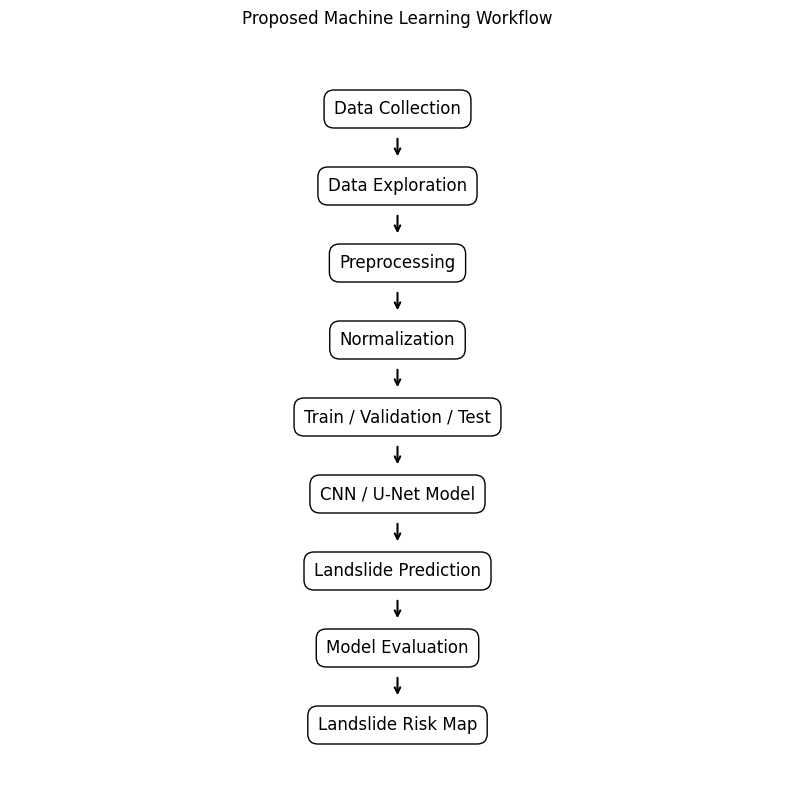

In [35]:
import matplotlib.pyplot as plt

steps = [
    "Data Collection",
    "Data Exploration",
    "Preprocessing",
    "Normalization",
    "Train / Validation / Test",
    "CNN / U-Net Model",
    "Landslide Prediction",
    "Model Evaluation",
    "Landslide Risk Map"
]

fig, ax = plt.subplots(figsize=(10, 10))

for i, step in enumerate(steps):
    y = len(steps) - i
    ax.text(
        0.5, y, step,
        ha="center",
        va="center",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.6", fill=False)
    )

    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(0.5, y - 0.65),
            xytext=(0.5, y - 0.35),
            arrowprops=dict(arrowstyle="->", lw=1.5)
        )

ax.set_xlim(0, 1)
ax.set_ylim(0, len(steps) + 1)
ax.axis("off")

plt.title("Proposed Machine Learning Workflow")
plt.show()

In [36]:
# Check the target values in the sample mask
print("Unique values in this sample mask:")
print(np.unique(mask))

# Count pixels belonging to each value
unique_values, counts = np.unique(mask, return_counts=True)

print("\nPixel distribution:")
for value, count in zip(unique_values, counts):
    print(f"Value {value}: {count} pixels")

Unique values in this sample mask:
[0]

Pixel distribution:
Value 0: 16384 pixels


## Conclusion

This project proposes a machine learning approach for predicting slope instability and structural-collapse risks in artisanal mining areas using environmental, topographic, and remote-sensing information.

For this assignment, a landslide remote-sensing dataset was selected as a relevant proxy because publicly available datasets containing sufficient historical artisanal mine-collapse events and corresponding environmental measurements are limited. The selected dataset contains image patches of size **128 × 128 pixels with 14 input channels**, together with corresponding landslide masks of size **128 × 128 pixels**.

The proposed workflow involves data collection, exploration, preprocessing, normalization, model training, prediction, and evaluation. A suitable deep learning segmentation model such as **U-Net or another CNN-based architecture** could be used to learn the relationship between the input remote-sensing/topographic data and landslide locations.

The results from this approach could provide a foundation for a future artisanal-mining safety system. With additional mining-specific data such as pit geometry, rainfall, soil properties, geology, mine locations, and surface displacement, the model could be extended to identify unstable mining slopes and support early-warning decisions aimed at reducing the risk of injuries, fatalities, and structural collapse.
